In [11]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv("../data/bank-full.csv", sep=";")
cot = df.value_counts("y")

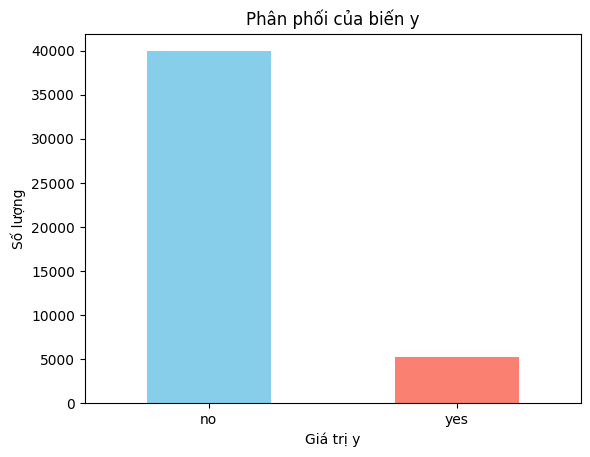

In [10]:
cot.plot(kind="bar", color =['skyblue','salmon'])

# Thêm tiêu đề và nhãn trục
plt.title("Phân phối của biến y")
plt.xlabel("Giá trị y")
plt.ylabel("Số lượng")
plt.xticks(rotation=0) 

# Hiển thị biểu đồ
plt.show()

In [5]:
# 3. Tách biến đầu vào X và biến mục tiêu y
X = df.drop("y", axis=1)
y = df["y"]

# 4. Chuyển biến categorical thành số
X = pd.get_dummies(X, drop_first=True)

# Chuyển target yes/no -> 1/0
y = y.map({"no": 0, "yes": 1})

In [6]:
# 5. Chia dữ liệu train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
# 6. Khởi tạo Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [8]:
# 7. Huấn luyện
rf_model.fit(X_train, y_train)

# 8. Dự đoán
y_pred = rf_model.predict(X_test)

In [9]:
# 9. Đánh giá
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Random Forest Accuracy: 0.9048988167643481

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.66      0.39      0.49      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.68      0.72      9043
weighted avg       0.89      0.90      0.89      9043


Confusion Matrix:
[[7771  214]
 [ 646  412]]


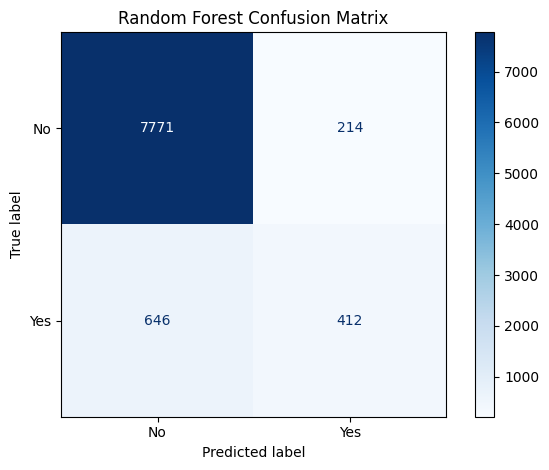

In [13]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()